# Exercise 1 — Planning observations with the ETC

*Covers notebooks 01–02. Difficulty: ★☆☆☆☆*

You are preparing a Lazuli proposal and need exposure times.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import slicersim

### 1.1 — A supernova

A SN Ia at $z=0.6$ with $x_1=1$, $c=-0.1$, observed 5 days before maximum light.
What exposure time is needed to reach an average SNR of 15 per resolution element in the
rest-frame 4000–7000 Å range?

In [2]:
exptime, snia = slicersim.lazuli_sn_etc("salt", redshift=0.6, x1=1, c=-0.1, phase=-5,
                                        snr=15, lbda_range=[4000, 7000], frame="rest")
print(f"{exptime:.0f} s = {exptime/3600:.2f} h", snia.get_readout_config())

1426 s = 0.40 h {'nmd': (63, 8, 0), 'nramps': 1}


### 1.2 — Twice the SNR

What exposure time is needed for SNR=30? Compare the ratio of exposure times with the factor 4
expected if SNR $\propto \sqrt{t}$. Look at the two readout configurations: why does
$\sqrt{t}$ hold here? Would it hold between SNR=5 and SNR=10?

*Hint: `get_exposure_time()` and `get_readout_config()` describe a target's current configuration.*

In [3]:
_ = snia.setup_to_snr(30, lbda_range=[4000, 7000], frame="rest")
exptime_30 = snia.get_exposure_time()
print(f"SNR=30: {exptime_30/3600:.2f} h, ratio = {exptime_30/exptime:.1f}", snia.get_readout_config())
# SNR=15 needs ~1 full ramp, SNR=30 needs ~4 ramps: independent ramps add up, SNR ∝ sqrt(nramps).

for snr in [5, 10]:
    _ = snia.setup_to_snr(snr, lbda_range=[4000, 7000], frame="rest")
    print(f"SNR={snr}: {snia.get_exposure_time():.0f} s", snia.get_readout_config())
# Within a single ramp, the SNR grows faster than sqrt(t) (the RON is paid once),
# so doubling the SNR costs less than 4 times the exposure time.

SNR=30: 1.61 h, ratio = 4.1 {'nmd': (64, 8, 0), 'nramps': 4}


SNR=5: 396 s {'nmd': (35, 4, 0), 'nramps': 1}


SNR=10: 747 s {'nmd': (33, 8, 0), 'nramps': 1}


### 1.3 — The spectrum

Plot the spectrum you would observe with the SNR=30 configuration (in erg/s/cm²/Å), together
with the true spectrum and its ±1σ band.

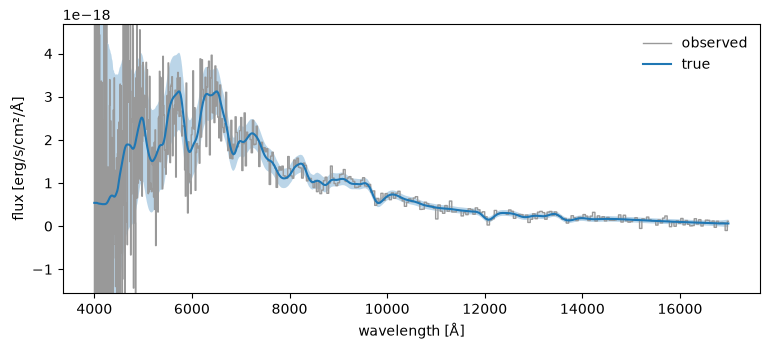

In [4]:
lbda, flux, variance = snia.get_spectrum(unit="flambda")
_, flux_true, _ = snia.get_spectrum(unit="flambda", incl_error=False)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(lbda, flux, color="0.6", lw=1, ds="steps-mid", label="observed")
ax.plot(lbda, flux_true, color="C0", label="true")
ax.fill_between(lbda, flux_true - np.sqrt(variance), flux_true + np.sqrt(variance), alpha=0.3)
ax.set_ylim(-0.5 * flux_true.max(), 1.5 * flux_true.max())
ax.set(xlabel="wavelength [Å]", ylabel="flux [erg/s/cm²/Å]")
ax.legend(frameon=False)

### 1.4 — Exposure time versus redshift

Plot the exposure time (in hours) needed to reach SNR=15 (rest-frame 4000–7000 Å) for the SN of
1.1 at redshifts 0.3, 0.5, 0.7, 0.9, 1.1 and 1.3.

*Hint: you do not need to rebuild the target for each redshift.*

[Text(0.5, 0, 'redshift'),
 Text(0, 0.5, 'exposure time [h]'),
 None,
 Text(0.5, 1.0, 'SN Ia, SNR=15')]

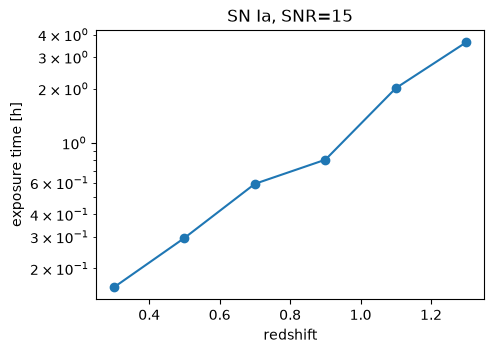

In [5]:
redshifts = [0.3, 0.5, 0.7, 0.9, 1.1, 1.3]
exptimes = []
for redshift in redshifts:
    snia.change_properties(redshift=redshift)
    _ = snia.setup_to_snr(15, lbda_range=[4000, 7000], frame="rest")
    exptimes.append(snia.get_exposure_time())

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(redshifts, np.asarray(exptimes) / 3600, "o-")
ax.set(xlabel="redshift", ylabel="exposure time [h]", yscale="log", title="SN Ia, SNR=15")

### 1.5 — A standard star and a flat spectrum

1. The CalSpec star GD71, rescaled to magnitude 20 in `sdssr`: exposure time for an average SNR
   of 50 per resolution element between 4000 and 10 000 Å (observer frame)?
2. A flat spectrum ($F_\lambda$ = constant) of magnitude 20 in `sdssr`, same requirement.
   Which one is faster to observe, and why?

In [6]:
star = slicersim.LazuliCalSpec("gd71", mag=20, band="sdssr")
_ = star.setup_to_snr(50, lbda_range=[4000, 10_000], frame="obs")
print(f"GD71 : {star.get_exposure_time():.0f} s")

lbda_in = np.arange(3000, 20_000, 1.0)
exptime_flat, _ = slicersim.lazuli_etc(lbda_in, np.ones_like(lbda_in), snr=50, mag=20, band="sdssr",
                                       lbda_range=[4000, 10_000], frame="obs")
print(f"flat : {exptime_flat:.0f} s")
# GD71 is a hot white dwarf: at the same r magnitude it has more flux in the blue,
# where the throughput is low and the SNR hard to get; the flat spectrum has more red flux.

GD71 : 1811 s


flat : 996 s
